In [856]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split, learning_curve
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

# Data analyzing

In [857]:
file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
file_path,
pandas_kwargs={
"nrows": 50_000, # choosing just the enough rows
"dtype": {'event_type': 'category',
       'product_id': 'int32',
       'category_code': 'category',
       'brand': 'category',
       'price': 'float32',
       'user_id': 'int32',
       }},

)

/tmp/ipykernel_63293/1109837127.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [858]:
pd.options.display.max_rows = 999

In [859]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [860]:
df['user_session'].value_counts()

user_session
02bbe799-dc61-44c9-a745-79f1eb80d732    91
d746fa12-0eb9-4c35-9876-375d70a98102    65
f85114d0-6167-4c8b-88f8-0cd1cfc2c10c    59
0997fafd-3233-4b93-962a-29623f16abd5    59
4486a9e0-a3ca-4464-9713-9eac5992a4c3    55
                                        ..
b36495db-4075-4dab-8a66-be07591fe995     1
8bb4ae5e-cc69-4449-961b-5aa0d982a208     1
715aed1d-07fb-4321-b538-e64433c9c756     1
2848dbf9-26b1-4eb0-ad64-6a73cb09752d     1
049f329c-83cd-40d3-a26b-859dac6c844e     1
Name: count, Length: 12798, dtype: int64

In [861]:
df.shape

(50000, 9)

In [862]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   event_time     50000 non-null  object  
 1   event_type     50000 non-null  category
 2   product_id     50000 non-null  int32   
 3   category_id    50000 non-null  int64   
 4   category_code  33902 non-null  category
 5   brand          42959 non-null  category
 6   price          50000 non-null  float32 
 7   user_id        50000 non-null  int32   
 8   user_session   50000 non-null  object  
dtypes: category(3), float32(1), int32(2), int64(1), object(2)
memory usage: 2.0+ MB


In [863]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.97352
purchase    0.01496
cart        0.01152
Name: proportion, dtype: float64

Data question:
-If you go and check unique values and count the unique values in event_type - there are only view, cart, and purchase values - no "removed from cart" value as claimed in the dataset description?
Answer: Correct. Unfortunately, this specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.
Source: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/discussion/132470

In [864]:
df.isnull().sum()/df.shape[0]

event_time       0.00000
event_type       0.00000
product_id       0.00000
category_id      0.00000
category_code    0.32196
brand            0.14082
price            0.00000
user_id          0.00000
user_session     0.00000
dtype: float64

In [865]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.709999,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [866]:
df['category_code'].nunique()

123

In [867]:
df['product_id'].nunique()

13289

In [868]:
df['category_id'].nunique()

490

In [869]:
df['category_code'].nunique()

123

In [870]:
df[df['event_type']=='purchase']['user_id'].nunique()

616

In [871]:
df[df['category_code']=='electronics.smartphone']['category_id'].value_counts()

category_id
2053013555631882655    13562
Name: count, dtype: int64

In [872]:
df[df['category_code']=='appliances.environment.water_heater'].value_counts()

event_time               event_type  product_id  category_id          category_code                        brand       price       user_id    user_session                        
2019-10-01 00:00:00 UTC  view        3900821     2053013552326770905  appliances.environment.water_heater  aqua        33.200001   554748717  9333dfbd-b87a-4708-9857-6336556b0fcc    1
2019-10-01 00:00:13 UTC  view        3900746     2053013552326770905  appliances.environment.water_heater  haier       102.379997  555444559  98b88fa0-d8fa-4b9d-8a71-3dd403afab85    1
2019-10-01 00:00:25 UTC  view        3900990     2053013552326770905  appliances.environment.water_heater  ariston     122.180000  554748717  5459fbe4-2aa5-42b9-9064-05f853218fe0    1
2019-10-01 00:00:31 UTC  view        3900746     2053013552326770905  appliances.environment.water_heater  haier       102.379997  555444559  98b88fa0-d8fa-4b9d-8a71-3dd403afab85    1
2019-10-01 00:01:00 UTC  view        3900930     2053013552326770905  appliances.envi

In [873]:
df[df['event_type']=='purchase'].value_counts()

event_time               event_type  product_id  category_id          category_code                        brand       price        user_id    user_session                        
2019-10-01 03:32:59 UTC  purchase    1005100     2053013555631882655  electronics.smartphone               samsung     154.380005   523763083  e860b0b7-6371-4cdd-95f6-0a95b2bd02ae    1
2019-10-01 00:02:14 UTC  purchase    1004856     2053013555631882655  electronics.smartphone               samsung     130.759995   543272936  8187d148-3c41-46d4-b0c0-9c08cd9dc564    1
2019-10-01 00:04:37 UTC  purchase    1002532     2053013555631882655  electronics.smartphone               apple       642.690002   551377651  3c80f0d6-e9ec-4181-8c5c-837a30be2d68    1
2019-10-01 00:07:07 UTC  purchase    13800054    2053013557418656265  furniture.bathroom.toilet            santeri     54.419998    555332717  1dea3ee2-2ded-42e8-8e7a-4e2ad6ae942f    1
2019-10-01 00:09:26 UTC  purchase    4804055     2053013554658804075  electronic

In [874]:
df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/tmp/ipykernel_63293/1857955882.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [875]:
df_groupby.sort_values(ascending=False)

category_code
electronics.smartphone                    361
electronics.audio.headphone                26
electronics.video.tv                       19
appliances.environment.vacuum              17
computers.notebook                         16
electronics.clocks                         16
appliances.kitchen.refrigerators           11
appliances.kitchen.washer                  11
electronics.telephone                       8
appliances.kitchen.blender                  6
apparel.shoes                               5
computers.desktop                           4
computers.peripherals.printer               4
accessories.bag                             4
appliances.kitchen.kettle                   4
appliances.environment.water_heater         3
auto.accessories.player                     3
kids.fmcg.diapers                           3
construction.tools.drill                    3
appliances.kitchen.oven                     3
appliances.environment.air_heater           3
appliances.sewing_ma

# Preprocessing

## Limitation aux catégories les plus vendues

In [876]:
top5 = ['electronics.smartphone', 'electronics.audio.headphone', 'electronics.video.tv',
'electronics.clocks', 'computers.notebook']

X = df[df['category_code'].isin(top5)]

In [877]:
X['category_code'].nunique()

5

In [878]:
X.shape

(18816, 9)

In [879]:
X[X['event_type']=='purchase'].shape

(438, 9)

In [880]:
X.isnull().sum()/X.shape[0]

event_time       0.000000
event_type       0.000000
product_id       0.000000
category_id      0.000000
category_code    0.000000
brand            0.017485
price            0.000000
user_id          0.000000
user_session     0.000000
dtype: float64

## Duplicates

In [881]:
X.duplicated().sort_values()

3        False
33369    False
33368    False
33365    False
33364    False
         ...  
3831      True
3830      True
15517     True
18817     True
3832      True
Length: 18816, dtype: bool

In [882]:
X.drop_duplicates()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101
16,2019-10-01 00:00:18 UTC,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5
...,...,...,...,...,...,...,...,...,...
49991,2019-10-01 03:32:58 UTC,view,21401057,2053013561579406073,electronics.clocks,NaN,100.129997,516415886,dab9fcec-5ecd-428a-914d-d60f3f73d32c
49992,2019-10-01 03:32:58 UTC,view,1003499,2053013555631882655,electronics.smartphone,oneplus,462.049988,532494760,868adf09-aa0c-49fe-b254-0b5df8be5882
49994,2019-10-01 03:32:59 UTC,view,1003768,2053013555631882655,electronics.smartphone,huawei,485.540009,543364311,9540e8ad-d8c6-467f-847f-3e5347a86e1f
49995,2019-10-01 03:32:59 UTC,purchase,1005100,2053013555631882655,electronics.smartphone,samsung,154.380005,523763083,e860b0b7-6371-4cdd-95f6-0a95b2bd02ae


## Modification format dates

In [883]:
X["event_time"] = pd.to_datetime(
    X["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

/tmp/ipykernel_63293/4073158124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["event_time"] = pd.to_datetime(


In [884]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18816 entries, 3 to 49997
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_time     18816 non-null  datetime64[ns]
 1   event_type     18816 non-null  category      
 2   product_id     18816 non-null  int32         
 3   category_id    18816 non-null  int64         
 4   category_code  18816 non-null  category      
 5   brand          18487 non-null  category      
 6   price          18816 non-null  float32       
 7   user_id        18816 non-null  int32         
 8   user_session   18816 non-null  object        
dtypes: category(3), datetime64[ns](1), float32(1), int32(2), int64(1), object(1)
memory usage: 929.0+ KB


## Concaténation

In [885]:
X_concat = (
    X.groupby(["user_session", "user_id", "category_id", "product_id"], as_index=False).
    agg({
        "event_type": " ".join,
        "event_time": (lambda x: x.max() - x.min()),
        "price": (lambda x: x.mean()),
        })
)

In [886]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,view,0 days 00:00:00,1181.500000
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,view view,0 days 00:00:54,1541.609985
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,view view view,0 days 00:01:32,1012.190002
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,view,0 days 00:00:00,348.529999


In [887]:
display(min(X_concat['event_time']), max(X_concat['event_time']))

Timedelta('0 days 00:00:00')

Timedelta('0 days 01:01:05')

In [888]:
X_concat['event_type'].value_counts()

event_type
view                                                                                                                                                                                                                                                                                                               8211
view view                                                                                                                                                                                                                                                                                                          2538
view view view                                                                                                                                                                                                                                                                                                      608
view view view view                                  

In [889]:
X_concat.shape

(12192, 7)

In [890]:
X_concat['user_session'].value_counts()

user_session
786ad8fa-f815-49fa-9ae5-b50efdcf6f89    32
2535e86b-ee7f-46b5-ac08-e7fb62495156    32
2483d9c1-9af4-46c1-8683-275c1cf3ee9a    32
a6a87556-4169-4a7c-b68e-2e71379f5397    30
67c789f1-e079-4b9b-9903-ac103f690742    30
                                        ..
fda235f4-e361-49ab-bdcd-5d06e6a3b6db     1
fda37748-1785-47cd-843e-b538608f7434     1
fdaab688-acd1-4997-b3b5-6622e828b866     1
fdb0cb1a-db16-44a3-945f-d6d5b5fb58dd     1
fd351eea-9a49-4060-b992-d312b5353b2b     1
Name: count, Length: 5525, dtype: int64

Ajout de la target

In [891]:
# X_concat['purchase'] = X_concat['event_type'].str.contains('purchase').apply(int)

In [892]:
X_concat.head(10)

,user_session,user_id,category_id,product_id,event_type,event_time,price
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,view,0 days 00:00:00,1181.500000
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,view view,0 days 00:00:54,1541.609985
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,view view view,0 days 00:01:32,1012.190002
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,view,0 days 00:00:00,348.529999
5,004217bc-db01-4503-a6cf-e00a2ea732ae,529162981,2053013554658804075,4804295,view,0 days 00:00:00,22.389999
6,0043d905-2c15-49e8-bd54-cb3db0de78ca,516062272,2053013555631882655,1004665,view,0 days 00:00:00,871.140015
7,007555fa-0ae0-4a1d-b7db-6989d9a5bdad,555465639,2053013555631882655,1004856,view,0 days 00:00:00,130.759995
8,008d7f4b-ed7a-484b-88bd-b0aacd787fb7,526073529,2053013561579406073,21411198,view,0 days 00:00:00,154.440002
9,009074dd-dda3-4032-9e3e-b45fed5fa579,520944953,2053013554415534427,1801806,view,0 days 00:00:00,124.449997


In [893]:
X_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12192 entries, 0 to 12191
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype          
---  ------        --------------  -----          
 0   user_session  12192 non-null  object         
 1   user_id       12192 non-null  int32          
 2   category_id   12192 non-null  int64          
 3   product_id    12192 non-null  int32          
 4   event_type    12192 non-null  object         
 5   event_time    12192 non-null  timedelta64[ns]
 6   price         12192 non-null  float32        
dtypes: float32(1), int32(2), int64(1), object(2), timedelta64[ns](1)
memory usage: 524.0+ KB


In [894]:
X_concat['event_type'].value_counts()

event_type
view                                                                                                                                                                                                                                                                                                               8211
view view                                                                                                                                                                                                                                                                                                          2538
view view view                                                                                                                                                                                                                                                                                                      608
view view view view                                  

In [895]:
X_concat['event_list'] = X_concat['event_type'].apply(str.split)

In [896]:
X_concat['event_list']

0                                      [view]
1                                      [view]
2                                [view, view]
3                          [view, view, view]
4                                      [view]
                         ...                 
12187                                  [view]
12188                      [view, view, view]
12189                                  [view]
12190                            [view, view]
12191    [view, view, view, view, view, view]
Name: event_list, Length: 12192, dtype: object

## Travail sur X_concat

In [897]:
X_concat['event_list']

0                                      [view]
1                                      [view]
2                                [view, view]
3                          [view, view, view]
4                                      [view]
                         ...                 
12187                                  [view]
12188                      [view, view, view]
12189                                  [view]
12190                            [view, view]
12191    [view, view, view, view, view, view]
Name: event_list, Length: 12192, dtype: object

In [898]:
X_concat['event_list'] = X_concat['event_list'].apply(lambda x: ['nothing'] if x==[] else x)

In [899]:
X_concat['event_list']

0                                      [view]
1                                      [view]
2                                [view, view]
3                          [view, view, view]
4                                      [view]
                         ...                 
12187                                  [view]
12188                      [view, view, view]
12189                                  [view]
12190                            [view, view]
12191    [view, view, view, view, view, view]
Name: event_list, Length: 12192, dtype: object

In [900]:
X_concat['even_list'] = X_concat['event_list'].apply(lambda x: ['nothing'] if x==[] else x)

In [901]:
X_concat['sequence_event'] = X_concat['event_list'].apply(" ".join)

In [902]:
X_concat['sequence_event']

0                                 view
1                                 view
2                            view view
3                       view view view
4                                 view
                     ...              
12187                             view
12188                   view view view
12189                             view
12190                        view view
12191    view view view view view view
Name: sequence_event, Length: 12192, dtype: object

In [903]:
X_concat['event_type'].nunique()

128

In [904]:
X_concat['event_len']=X_concat['event_type'].apply(lambda x: len(x.split()))

In [905]:
X_concat

,user_session,user_id,category_id,product_id,event_type,event_time,price,event_list,even_list,sequence_event,event_len
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999,[view],[view],view,1
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,view,0 days 00:00:00,1181.500000,[view],[view],view,1
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,view view,0 days 00:00:54,1541.609985,"[view, view]","[view, view]",view view,2
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,view view view,0 days 00:01:32,1012.190002,"[view, view, view]","[view, view, view]",view view view,3
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,view,0 days 00:00:00,348.529999,[view],[view],view,1
...,...,...,...,...,...,...,...,...,...,...,...
12187,ffc72f0a-6428-5bdd-9032-90c2067bc115,527718171,2053013555631882655,1004681,view,0 days 00:00:00,191.770004,[view],[view],view,1
12188,ffcc0776-319e-40f8-919e-1e30cd26d146,512946579,2053013555631882655,1004856,view view view,0 days 00:00:54,130.759995,"[view, view, view]","[view, view, view]",view view view,3
12189,ffd831c5-90ca-49b0-bdec-102412bd17d0,520357432,2053013555631882655,1004749,view,0 days 00:00:00,203.350006,[view],[view],view,1
12190,ffd831c5-90ca-49b0-bdec-102412bd17d0,520357432,2053013555631882655,1004833,view view,0 days 00:01:37,174.759995,"[view, view]","[view, view]",view view,2


In [906]:
display(min(X_concat['event_len']), max(X_concat['event_len']))

1

48

In [907]:
X_concat['duration_mean'] = X_concat['event_time'] / X_concat['event_len']

In [908]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price,event_list,even_list,sequence_event,event_len,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999,[view],[view],view,1,0 days 00:00:00
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,view,0 days 00:00:00,1181.500000,[view],[view],view,1,0 days 00:00:00
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,view view,0 days 00:00:54,1541.609985,"[view, view]","[view, view]",view view,2,0 days 00:00:27
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,view view view,0 days 00:01:32,1012.190002,"[view, view, view]","[view, view, view]",view view view,3,0 days 00:00:30.666666666
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,view,0 days 00:00:00,348.529999,[view],[view],view,1,0 days 00:00:00


In [909]:
X_concat.describe()

,user_id,category_id,product_id,event_time,price,event_len,duration_mean
count,1.219200e+04,1.219200e+04,1.219200e+04,12192,12192.000000,12192.000000,12192
mean,5.331458e+08,2.053037e+18,2.496147e+06,0 days 00:00:49.417158792,484.436890,1.543307,0 days 00:00:17.099637684
std,1.666645e+07,1.135504e+15,4.526499e+06,0 days 00:02:57.821851316,450.219818,1.191015,0 days 00:01:01.233072054
min,4.096869e+08,2.053014e+18,1.001588e+06,0 days 00:00:00,0.000000,1.000000,0 days 00:00:00
25%,5.165814e+08,2.053014e+18,1.004659e+06,0 days 00:00:00,169.307495,1.000000,0 days 00:00:00
50%,5.316365e+08,2.053014e+18,1.004903e+06,0 days 00:00:00,295.760010,1.000000,0 days 00:00:00
75%,5.506298e+08,2.053014e+18,1.306796e+06,0 days 00:00:28,733.919983,2.000000,0 days 00:00:13
max,5.554732e+08,2.109094e+18,4.550001e+07,0 days 01:01:05,2574.070068,48.000000,0 days 00:26:29


In [910]:
X_concat.loc[X_concat['event_time']>'0 days 00:02:00']['user_session'].nunique()

912

In [911]:
X.loc[X['user_session']=='0d6fd875-6b0f-46ca-a75a-257917490b25']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session


In [912]:
df.loc[df['user_session']=='0d6fd875-6b0f-46ca-a75a-257917490b25']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session


In [913]:
X['category_code'].value_counts()

category_code
electronics.smartphone                    13562
electronics.clocks                         1623
computers.notebook                         1437
electronics.audio.headphone                1169
electronics.video.tv                       1025
apparel.dress                                 0
apparel.costume                               0
apparel.belt                                  0
accessories.bag                               0
accessories.umbrella                          0
accessories.wallet                            0
apparel.shoes.ballet_shoes                    0
apparel.shoes.espadrilles                     0
apparel.shoes.keds                            0
apparel.shoes.moccasins                       0
apparel.shoes.sandals                         0
apparel.shoes.slipons                         0
apparel.shoes.step_ins                        0
apparel.shorts                                0
apparel.skirt                                 0
apparel.sock              

In [914]:
X_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12192 entries, 0 to 12191
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_session    12192 non-null  object         
 1   user_id         12192 non-null  int32          
 2   category_id     12192 non-null  int64          
 3   product_id      12192 non-null  int32          
 4   event_type      12192 non-null  object         
 5   event_time      12192 non-null  timedelta64[ns]
 6   price           12192 non-null  float32        
 7   event_list      12192 non-null  object         
 8   even_list       12192 non-null  object         
 9   sequence_event  12192 non-null  object         
 10  event_len       12192 non-null  int64          
 11  duration_mean   12192 non-null  timedelta64[ns]
dtypes: float32(1), int32(2), int64(2), object(5), timedelta64[ns](2)
memory usage: 1000.2+ KB


In [915]:
# X_preprocessed = pd.merge(X_concat, .drop(columns=['event_time', 'event_type', 'brand', 'category_code', 'category_id']), on=['user_session', 'user_id', 'product_id'], how='left')

In [916]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price,event_list,even_list,sequence_event,event_len,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999,[view],[view],view,1,0 days 00:00:00
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,view,0 days 00:00:00,1181.500000,[view],[view],view,1,0 days 00:00:00
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,view view,0 days 00:00:54,1541.609985,"[view, view]","[view, view]",view view,2,0 days 00:00:27
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,view view view,0 days 00:01:32,1012.190002,"[view, view, view]","[view, view, view]",view view view,3,0 days 00:00:30.666666666
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,view,0 days 00:00:00,348.529999,[view],[view],view,1,0 days 00:00:00


In [917]:
X_concat.rename(columns={'event_time': 'duration', 'event_len': 'sequence_len'}, inplace=True)

In [918]:
X_concat = X_concat.loc[X_concat['sequence_len']<8]

In [919]:
X_concat.shape

(12145, 12)

## Définition de la target

In [920]:
y = X_concat['event_list'].apply(lambda x: x.pop())

In [921]:
y

0        view
1        view
2        view
3        view
4        view
         ... 
12187    view
12188    view
12189    view
12190    view
12191    view
Name: event_list, Length: 12145, dtype: object

In [922]:
y.value_counts()

event_list
view        11934
purchase      144
cart           67
Name: count, dtype: int64

In [923]:
y = y.apply(lambda x: 1 if x=='purchase' else 0)

In [924]:
y.shape

(12145,)

In [938]:
y.value_counts()

event_list
0    12001
1      144
Name: count, dtype: int64

## X_preprocessed

In [925]:
X_preprocessed = X_concat.drop(columns=['event_type', 'event_list'])

In [926]:
X_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12145 entries, 0 to 12191
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_session    12145 non-null  object         
 1   user_id         12145 non-null  int32          
 2   category_id     12145 non-null  int64          
 3   product_id      12145 non-null  int32          
 4   duration        12145 non-null  timedelta64[ns]
 5   price           12145 non-null  float32        
 6   even_list       12145 non-null  object         
 7   sequence_event  12145 non-null  object         
 8   sequence_len    12145 non-null  int64          
 9   duration_mean   12145 non-null  timedelta64[ns]
dtypes: float32(1), int32(2), int64(2), object(3), timedelta64[ns](2)
memory usage: 901.4+ KB


In [927]:
X_preprocessed['sequence_len'].mean()

np.float64(1.504569781803211)

<Axes: >

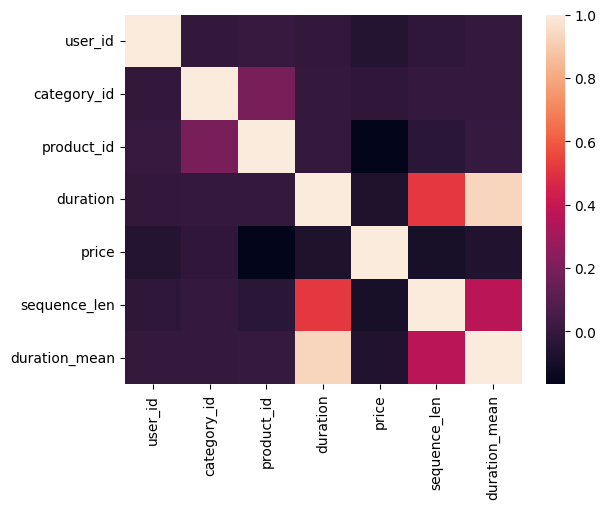

In [928]:
sns.heatmap(X_preprocessed.select_dtypes(include=np.number).corr())

In [929]:
X_preprocessed.head()

,user_session,user_id,category_id,product_id,duration,price,even_list,sequence_event,sequence_len,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,0 days 00:00:00,231.639999,[],view,1,0 days 00:00:00
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,0 days 00:00:00,1181.500000,[],view,1,0 days 00:00:00
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,0 days 00:00:54,1541.609985,[view],view view,2,0 days 00:00:27
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,0 days 00:01:32,1012.190002,"[view, view]",view view view,3,0 days 00:00:30.666666666
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,0 days 00:00:00,348.529999,[],view,1,0 days 00:00:00


In [930]:
X_preprocessed['duration_mean_second'] = X_preprocessed['duration_mean'].dt.total_seconds()

In [931]:
X_preprocessed.head()

,user_session,user_id,category_id,product_id,duration,price,even_list,sequence_event,sequence_len,duration_mean,duration_mean_second
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,0 days 00:00:00,231.639999,[],view,1,0 days 00:00:00,0.000000
1,00322ee2-5eec-4647-9499-eae70633ec5b,525961138,2053013555631882655,1005108,0 days 00:00:00,1181.500000,[],view,1,0 days 00:00:00,0.000000
2,00334c2e-e8e5-463f-ae4e-f44f9796ccf4,517062545,2053013555631882655,1005143,0 days 00:00:54,1541.609985,[view],view view,2,0 days 00:00:27,27.000000
3,00399d10-e0d3-4d17-9760-30c42851777c,514523666,2053013555631882655,1004227,0 days 00:01:32,1012.190002,"[view, view]",view view view,3,0 days 00:00:30.666666666,30.666667
4,003bed4d-9bf0-4f48-bab5-8424f4ba0762,512531454,2053013555631882655,1004957,0 days 00:00:00,348.529999,[],view,1,0 days 00:00:00,0.000000


In [932]:
X_preprocessed.shape

(12145, 11)

In [933]:
y.shape

(12145,)

## Train test split

In [934]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3)

## Undersampling

In [935]:
rus = RandomUnderSampler(sampling_strategy=0.5,random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

In [936]:
print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()

(312, 11)
(312,)


event_list
0    208
1    104
Name: count, dtype: int64

## Encoding

In [939]:
encoder = OneHotEncoder(sparse_output=False, drop="if_binary", handle_unknown="ignore").set_output(transform='pandas')

X_train_encoded = encoder.fit_transform(X_train_res[['sequence_event', 'category_id']])

In [940]:
X_test_encoded = encoder.transform(X_test[['sequence_event', 'category_id']])

/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Scaling

In [941]:
scaler = RobustScaler().set_output(transform='pandas')

X_train_scaled = scaler.fit_transform(X_train_res[['duration_mean_second', 'price']])
X_test_scaled = scaler.transform(X_test[['duration_mean_second', 'price']])

## Concaténation des X_train et X_test

In [942]:
X_train_processed = pd.concat([X_train_encoded, X_train_scaled], axis=1)
X_test_processed = pd.concat([X_test_encoded, X_test_scaled], axis=1)

In [943]:
X_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 7323 to 9505
Data columns (total 37 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sequence_event_purchase                                    312 non-null    float64
 1   sequence_event_view                                        312 non-null    float64
 2   sequence_event_view cart cart cart purchase                312 non-null    float64
 3   sequence_event_view cart cart cart view purchase           312 non-null    float64
 4   sequence_event_view cart cart purchase                     312 non-null    float64
 5   sequence_event_view cart cart view                         312 non-null    float64
 6   sequence_event_view cart cart view cart purchase           312 non-null    float64
 7   sequence_event_view cart cart view view purchase           312 non-null    float64
 8   sequence_ev

In [944]:
X_train_processed.head()

,sequence_event_purchase,sequence_event_view,sequence_event_view cart cart cart purchase,sequence_event_view cart cart cart view purchase,sequence_event_view cart cart purchase,sequence_event_view cart cart view,sequence_event_view cart cart view cart purchase,sequence_event_view cart cart view view purchase,sequence_event_view cart purchase,sequence_event_view cart purchase view,...,sequence_event_view view view view view cart purchase,sequence_event_view view view view view purchase,category_id_2053013553341792533,category_id_2053013554415534427,category_id_2053013554658804075,category_id_2053013555631882655,category_id_2053013558920217191,category_id_2053013561579406073,duration_mean_second,price
7323,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.174419,-0.209967
6719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.453488,-0.297655
8695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.023256,-0.366235
362,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.174419,-0.494827
2189,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.174419,1.941141


# Entrainement du modèle

In [945]:
model = LogisticRegression(class_weight='balanced', random_state=42)

model.fit(X_train_processed, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Metrics

In [946]:
cv_results = cross_validate(model, X_train_processed, y_train_res, scoring=['f1', 'recall', 'precision', 'accuracy'])
cv_results

{'fit_time': array([0.01722026, 0.02356553, 0.10649562, 0.087919  , 0.04437685]),
 'score_time': array([0.05166197, 0.03897214, 0.0520494 , 0.03803706, 0.028409  ]),
 'test_f1': array([0.95454545, 0.95454545, 0.93023256, 0.95454545, 0.95454545]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.91304348, 0.91304348, 0.86956522, 0.91304348, 0.91304348]),
 'test_accuracy': array([0.96825397, 0.96825397, 0.9516129 , 0.96774194, 0.96774194])}

In [947]:
train_sizes = np.arange(20, 260, 20)

# Get train scores (precision), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=LogisticRegression(class_weight='balanced'), X=X_train_processed, y=y_train_res, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
40 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python3

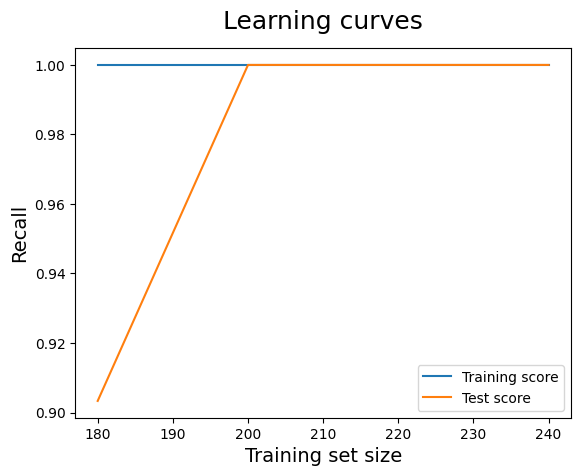

In [948]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [949]:
train_scores

array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.],
       [ 1.,  1.,  1.,  1.,  1.]])

In [854]:
display(df['event_time'].min(), df['event_time'].max())

'2019-10-01 00:00:00 UTC'

'2019-10-01 03:32:59 UTC'

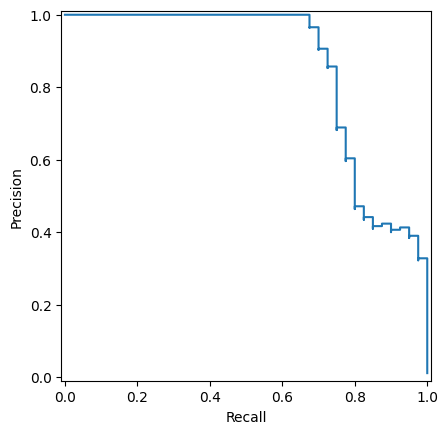

In [950]:
y_pred_proba = model.predict_proba(X_test_processed)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()